# Creating Time Series Plots for PACE Level 3 Oceanic Data
Goal of notebook: Plot time series of PACE data, including *Chlorophyll-a (Chl-a), Particulate Organic Carbon (POC), Diffuse Attentuation at 490 nm (Kd490), and Carbon (C)* </p> 
***

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
from datetime import datetime
import matplotlib.dates as mdates

In [ ]:
# create chl-a dataframe
df_chla = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/chla_PACE_timeseries_8D_PACE_OCI_L3M_CHL.csv')
df_chla = df_chla.drop(columns = 'Unnamed: 0')
df_chla = df_chla.rename(columns = {'Kd median:': 'Kd median'})

# create poc dataframe
df_poc = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/POC_PACE_timeseries_8D_PACE_OCI_L3M_POC.csv')
df_poc = df_poc.drop(columns = 'Unnamed: 0')

# create kd490 dataframe
df_kd = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/kd490_PACE_timeseries_8D_PACE_OCI_L3M_KD.csv')
df_kd = df_kd.drop(columns = 'Unnamed: 0')

# create carbon dataframe
df_C = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/C_PACE_timeseries_8D_PACE_OCI_L3M_CARBON.csv')
df_C = df_C.drop(columns = 'Unnamed: 0')

# Plot data based on variable of interest

In [19]:
df_chla = pd.read_csv('chla_PACE_timeseries_8D_PACE_OCI_L3M_CHL.csv')
df_chla = df_chla.drop(columns = 'Unnamed: 0')
#df_chla

In [43]:
# vois = chla, poc, kd490, c
# specify which you want to examine
voi = 'chla'

# set df as the desired dataframe corresponding to the voi. additionally, set the variable name and unit
if voi == 'chla':
    df = df_chla
    variable = 'Chlorophyll-a'
    unit = '(mg m$^{-3}$)'
elif voi == 'poc':
    df = df_poc
    variable = 'POC'
    unit = '(mg m$^{-3}$)'
elif voi == 'kd490':
    df = df_kd
    variable = 'Kd490'
    unit = '(m$^{-1}$)'
else:
    df = df_C
    variable = 'C'
    variable = '(mg m$^{-3}$)'

In [45]:
df

,start date,end date,start year,start month,start day,end year,end month,end day,chla mean,chla geometric mean,chla median,chla std,chla geometric std,chla variance,chla N,chla IQR
0,2024-03-05,2024-03-12,2024,3,5,2024,3,12,0.060554,0.058686,0.057316,0.015550,1.282235,0.000242,14760,0.020840
1,2024-03-13,2024-03-20,2024,3,13,2024,3,20,0.071786,0.069004,0.069807,0.019872,1.330306,0.000395,21290,0.028535
2,2024-03-21,2024-03-28,2024,3,21,2024,3,28,0.054753,0.053297,0.051695,0.013200,1.257521,0.000174,23832,0.015745
3,2024-03-29,2024-04-05,2024,3,29,2024,4,5,0.057085,0.054190,0.052664,0.018550,1.381122,0.000344,21939,0.030348
4,2024-04-06,2024-04-13,2024,4,6,2024,4,13,0.062426,0.059528,0.058069,0.020088,1.355341,0.000404,22307,0.026204
5,2024-04-14,2024-04-21,2024,4,14,2024,4,21,0.057482,0.056418,0.054103,0.011673,1.208413,0.000136,20095,0.014666
6,2024-04-22,2024-04-29,2024,4,22,2024,4,29,0.045897,0.044872,0.044380,0.010719,1.230832,0.000115,15877,0.012283
7,2024-04-30,2024-05-07,2024,4,30,2024,5,7,0.052823,0.049327,0.048542,0.026568,1.410908,0.000706,7906,0.023385
8,2024-05-08,2024-05-15,2024,5,8,2024,5,15,0.050035,0.048501,0.047975,0.012719,1.282000,0.000162,5804,0.016111
9,2024-05-16,2024-05-23,2024,5,16,2024,5,23,0.054675,0.051481,0.046989,0.020031,1.404588,0.000401,3908,0.027614


In [46]:
# create objects
start_date = df['start date'].values.copy()
end_date = df['end date'].values.copy()
mean = df['chla mean'].values.copy()
gmean = df['chla geometric mean'].values.copy()
median = df['chla median'].values.copy()
std = df['chla std'].values.copy()
gstd = df['chla geometric std'].values.copy()
var = df['chla variance'].values.copy()
N = df['chla N'].values.copy()

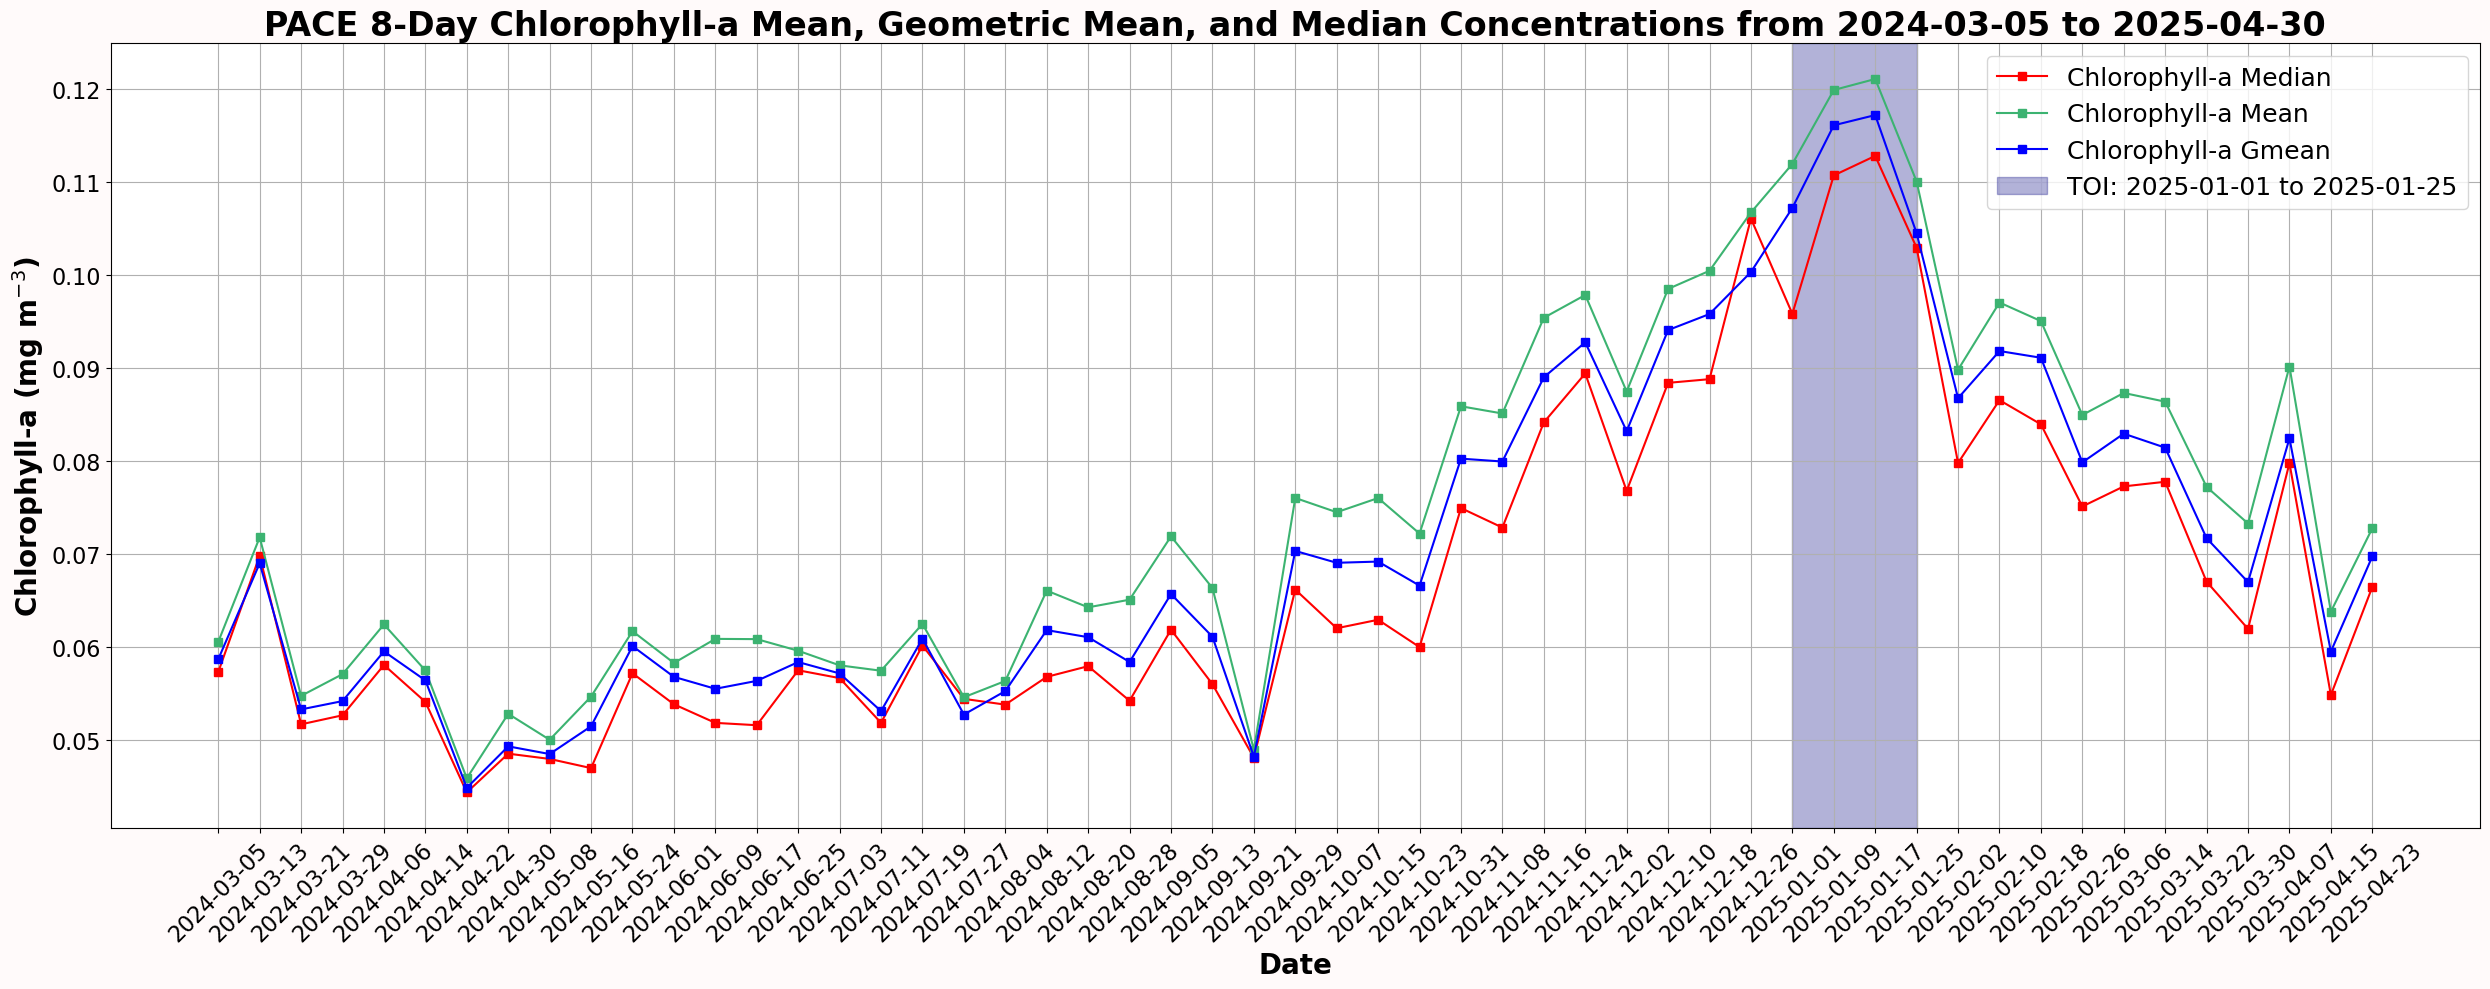

In [49]:
# plot data
fig = plt.figure(figsize = (25,10), facecolor = 'snow')

plt.plot(start_date, median, linestyle = '-', color = 'red', marker='s', label = f'{variable} Median')
plt.plot(start_date, mean, linestyle = '-', color = 'mediumseagreen', marker='s', label = f'{variable} Mean')
plt.plot(start_date, gmean, linestyle = '-', color = 'blue', marker='s', label = f'{variable} Gmean')
start_toi = '2025-01-01'
end_toi = '2025-01-25'
plt.axvspan(start_toi, end_toi, label = f'TOI: {start_toi} to {end_toi}', color = 'navy', alpha = 0.3)

plt.tick_params(axis = 'x', rotation=45, labelsize = 16)
plt.tick_params(axis = 'y', labelsize = 16)
plt.grid(True)
plt.ylabel(f'{variable} {unit}', fontsize = 20, fontweight = 'bold') #rotation = 0, labelpad = 130)
plt.xlabel('Date', fontsize = 20, fontweight = 'bold', rotation = 0)
plt.legend(loc='upper right', fontsize = 18)
plt.title(f'PACE 8-Day {variable} Mean, Geometric Mean, and Median Concentrations from {start_date[0]} to {end_date[-1]}', fontsize = 24, fontweight = 'bold')

plt.tight_layout()
#plt.savefig(f'/home/jovyan/Desktop/figures/PACE/PACE 8-Day {variable} Concentrations', bbox_inches = 'tight', dpi = 300)

# Plot two variables against each other

In [ ]:
# make two dataframes: 1 and 2
df_1 = df_chla 
df_2 = df_kd

In [ ]:
# create objects
# CHLA
start_date = df_chla['start date'].values.copy()
end_date = df_chla['end date'].values.copy() # same dates, so no need to declare twice in kd490 block
chla_mean = df_chla['chla mean'].values.copy()
chla_gmean = df_chla['chla geometric mean'].values.copy()
chla_median = df_chla['chla median'].values.copy()
chla_std = df_chla['chla std'].values.copy()
chla_gstd = df_chla['chla geometric std'].values.copy()
chla_var = df_chla['chla variance'].values.copy()
chla_N = df_chla['chla N'].values.copy()

# KD490
kd490_mean = df_kd490['Kd mean'].values.copy()
kd490_gmean = df_kd490['Kd geometric mean'].values.copy()
kd490_median = df_kd490['Kd median'].values.copy()
kd490_std = df_kd490['Kd std'].values.copy()
kd490_gstd = df_kd490['Kd geometric std'].values.copy()
kd490_var = df_kd490['Kd variance'].values.copy()
kd490_N = df_kd490['Kd N'].values.copy()

In [ ]:
start_date = pd.to_datetime(start_date)  # replace your list/array with datetime version
start_toi = pd.to_datetime('2025-01-07')
end_toi = pd.to_datetime('2025-01-31')

# make figure
fig, ax = plt.subplots(figsize = (28,10), facecolor = 'snow')

# plot chl-a data first
ax.plot(start_date, chla_gmean, linestyle = '-', color = 'mediumseagreen', marker='s', label = f'Chlorophyll-a Gmean')
ax.tick_params(axis = 'y', labelsize = 17)
ax.set_ylabel(f'Chlorophyll-a \n Geometric Mean \n {chla_unit}', fontsize = 20, fontweight = 'bold', rotation = 0, va='center', labelpad = 100)

# plot kd data first
ax1 = ax.twinx()
ax1.plot(start_date, kd490_gmean, linestyle = '-', color = 'blue', marker='s', label = f'Kd490 Gmean')
ax1.tick_params(axis = 'y', labelsize = 17)
ax1.set_ylabel(f'Diffuse \n Attenuation \n at 490 nm \n (Kd490) \n{kd490_unit}', fontsize = 20, fontweight = 'bold', va='center', rotation = 0, labelpad = 80)

# set xticks
tick_positions = start_date[::2] 
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_positions, rotation=45, fontsize=16)
ax.set_xlim(start_date.min(), start_date.max())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# set grid details
ax.grid(True)
ax.xaxis.grid(color = 'k', alpha=0.4, linewidth=1)
ax.yaxis.grid(color = 'mediumseagreen', alpha = 0.5, linewidth=1.5)
ax1.grid(True)
ax1.yaxis.grid(color = 'blue', alpha=0.5, linewidth=1.5)

# Label and legend
ax.set_xlabel('Date', fontsize=20, fontweight='bold')
lines, labels = ax.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
legend = ax.legend(lines + lines1, labels + labels1, loc='upper right', fontsize=18)
legend.get_frame().set_edgecolor('black')    
legend.get_frame().set_linewidth(1.5)        
legend.get_frame().set_facecolor('snow')

# set toi
ax1.axvspan(start_toi, end_toi,color = 'green', alpha = 0.2, label=f'TOI: {start_toi.date()} to {end_toi.date()}')

plt.xlabel('Date', fontsize = 20, fontweight = 'bold', rotation = 0)

start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)
plt.title(f'PACE 8-Day Chlorophyll-a and Kd490 Geometric Mean Concentrations from {start_date[0].strftime("%Y-%m-%d")} to {end_date[-1].strftime("%Y-%m-%d")}', fontsize = 25, fontweight = 'bold', pad = 15)
plt.tight_layout()

## Zoomed view

In [ ]:
start_date = pd.to_datetime(start_date)  # replace your list/array with datetime version
start_toi = pd.to_datetime('2025-01-07')
end_toi = pd.to_datetime('2025-01-31')

# make figure
fig, ax = plt.subplots(figsize = (25,10), facecolor = 'snow')

# plot chl-a data first
ax.plot(start_date, chla_gmean, linestyle = '-', color = 'mediumseagreen', marker='s', label = f'Chlorophyll-a Gmean')
ax.tick_params(axis = 'y', labelsize = 17)
ax.set_ylabel(f'Chlorophyll-a \n Geometric Mean \n {chla_unit}', fontsize = 20, fontweight = 'bold', rotation = 0, va='center', labelpad = 100)
ax.set_ylim(0.05,0.16)
    
# plot kd data first
ax1 = ax.twinx()
ax1.plot(start_date, kd490_gmean, linestyle = '-', color = 'blue', marker='s', label = f'Kd490 Gmean')
ax1.tick_params(axis = 'y', labelsize = 17)
ax1.set_ylabel(f'Diffuse \n Attenuation \n at 490 nm \n (Kd490) \n{kd490_unit}', fontsize = 20, fontweight = 'bold', va='center', rotation = 0, labelpad = 75)
ax1.set_ylim(0.028,0.037)

# set limit
zoom_x_min = datetime.strptime('2024-11-08', '%Y-%m-%d')
zoom_x_max = datetime.strptime('2025-03-29', '%Y-%m-%d')
ax.set_xlim(zoom_x_min, zoom_x_max)
start_date = pd.to_datetime(start_date)
tick_dates = [d for d in start_date if zoom_x_min <= d <= zoom_x_max]
ax.set_xticks(tick_dates)  # Set tick positions
ax.tick_params(axis='x', labelsize=16, rotation=45)  # Rotate & resize
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


# set grid details
ax.grid(True)
ax.xaxis.grid(color = 'k', alpha=0.4, linewidth=1)
ax.yaxis.grid(color = 'mediumseagreen', alpha = 0.5, linewidth=1.5)
ax1.grid(True)
ax1.yaxis.grid(color = 'blue', alpha=0.5, linewidth=1.5)

# set toi
ax1.axvspan(start_toi, end_toi,color = 'green', alpha = 0.2, label=f'TOI: {start_toi.date()} to {end_toi.date()}')

# Label and legend
ax.set_xlabel('Date', fontsize=20, fontweight='bold')
lines, labels = ax.get_legend_handles_labels()
lines1, labels1 = ax1.get_legend_handles_labels()
legend = ax.legend(lines + lines1, labels + labels1, loc='upper right', fontsize=18)
legend.get_frame().set_edgecolor('black')    
legend.get_frame().set_linewidth(1.5)        
legend.get_frame().set_facecolor('snow')

start, end = tick_dates[0].strftime('%Y-%m-%d'), tick_dates[-1].strftime('%Y-%m-%d')
plt.xlabel('Date', fontsize = 20, fontweight = 'bold', rotation = 0)
plt.title(f'PACE 8-Day Chlorophyll-a and Kd490 Geometric Mean Concentrations from {start} to {end}', fontsize = 25, fontweight = 'bold', pad = 15)
plt.tight_layout()

# Plot a ratio of two variables

In [66]:
# set dataframes, num and den
num = df_poc
den = df_chla

NameError: name 'df_poc' is not defined

In [ ]:
# set objects
start_date = df_chla['start date'].values.copy()
end_date = df_chla['end date'].values.copy()

# examining select values. here, we use the geometric mean values
chla_gmean = df_chla['chla geometric mean'].values.copy()
poc_gmean = df_poc['POC geometric mean'].values.copy()
kd_gmean = df_kd['Kd geometric mean'].values.copy()
C_gmean = df_C['C geometric mean'].values.copy()

In [ ]:
# define ratio
ratio = poc_gmean/chla_gmean

In [ ]:
# plot the ratio
fig = plt.figure(figsize = (25,10), facecolor = 'snow')

plt.plot(start_date, ratio, linestyle = '-', color = 'red', marker='s', label = f'POC Gmean')

start_toi = '2025-01-01'
end_toi = '2025-01-25'
plt.axvspan(start_toi, end_toi, label = f'TOI: {start_toi} to {end_toi}', color = 'navy', alpha = 0.3)

plt.tick_params(axis = 'x', rotation=45, labelsize = 16)
plt.tick_params(axis = 'y', labelsize = 16)
plt.grid(True)
#plt.ylabel(f'{variable} {chla_unit}', fontsize = 20, fontweight = 'bold') #rotation = 0, labelpad = 130)
plt.xlabel('Date', fontsize = 20, fontweight = 'bold', rotation = 0)
plt.legend(loc='upper right', fontsize = 18)
plt.title(f'PACE 8-Day Geometric Mean Concentrations from {start_date[0]} to {end_date[-1]}', fontsize = 24, fontweight = 'bold')

plt.tight_layout()